# EDA + Crop Yield Prediction using India District-Wise Rainfall and Crop Yield Dataset (2014–2024)

## Project Overview

Agriculture plays a major role in India’s economy, and crop productivity is strongly influenced by rainfall, temperature, humidity, irrigation methods, and soil quality.

This project uses a district-level agricultural dataset from 2014–2024 to perform:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Crop Yield Prediction
- Machine Learning Regression Modeling
- Feature Importance Analysis

The main goal is to understand how environmental and agricultural factors affect crop yield and to build a predictive model for agricultural forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

plt.style.use('ggplot')

# Load Dataset

In [2]:
df=pd.read_csv('/kaggle/input/datasets/tushardobal/india-rainfall-and-crop-yield-dataset-20142024/india_rainfall_crop_yield_2014_2024.csv')
df.head()

,Record_ID,State,District,Year,Season,Crop_Type,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Soil_Type,Irrigation_Type,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR
0,1,Uttarakhand,Dehradun,2014,Kharif,Rice,445.02,23.5,47.3,Black,Sprinkler,344.59,42.22,4471.68,1.83,34361.86,67904.0
1,2,Uttarakhand,Dehradun,2014,Rabi,Wheat,1410.24,32.3,73.6,Red,Rain-fed,217.81,29.71,1463.13,7.55,52216.79,106010.0
2,3,Uttarakhand,Dehradun,2014,Kharif,Maize,787.56,33.3,40.6,Laterite,Canal,201.97,24.74,1785.38,3.13,14302.87,70380.0
3,4,Uttarakhand,Dehradun,2014,Kharif,Cotton,1892.93,30.4,82.4,Alluvial,Tube Well,280.94,43.75,324.54,2.86,27337.56,8166.0
4,5,Uttarakhand,Dehradun,2014,Zaid,Cotton,1216.14,34.7,43.9,Black,Drip,192.11,41.86,3538.92,6.19,15784.33,314345.0


# Basic Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Record_ID                 7920 non-null   int64  
 1   State                     7920 non-null   object 
 2   District                  7920 non-null   object 
 3   Year                      7920 non-null   int64  
 4   Season                    7920 non-null   object 
 5   Crop_Type                 7920 non-null   object 
 6   Rainfall_mm               7920 non-null   float64
 7   Avg_Temperature_C         7920 non-null   float64
 8   Humidity_percent          7920 non-null   float64
 9   Soil_Type                 7920 non-null   object 
 10  Irrigation_Type           7920 non-null   object 
 11  Fertilizer_Used_kg        7920 non-null   float64
 12  Pesticide_Used_kg         7920 non-null   float64
 13  Cultivated_Area_hectares  7920 non-null   float64
 14  Yield_to

In [4]:
df.describe()

,Record_ID,Year,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR
count,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000,7920.000000
mean,3960.500000,2019.000000,1303.157420,28.070985,62.466869,250.312962,32.569508,2563.768706,4.832213,38279.748221,160679.954672
std,2286.451399,3.162477,516.667333,5.806386,15.817427,114.850492,15.916997,1414.030920,2.127995,15273.022319,126720.323375
min,1.000000,2014.000000,400.800000,18.000000,35.000000,50.170000,5.000000,100.650000,1.200000,12014.350000,1495.000000
25%,1980.750000,2016.000000,855.280000,23.000000,49.000000,149.957500,18.650000,1331.842500,2.950000,25045.967500,60727.500000
50%,3960.500000,2019.000000,1305.420000,28.100000,62.700000,251.350000,32.860000,2567.445000,4.850000,38261.045000,129250.500000
75%,5940.250000,2022.000000,1752.057500,33.200000,76.000000,350.692500,46.302500,3796.015000,6.680000,51779.057500,228904.750000
max,7920.000000,2024.000000,2199.580000,38.000000,90.000000,449.900000,59.980000,4999.300000,8.500000,64998.760000,721789.000000


In [5]:
df.isnull().sum()

Record_ID                   0
State                       0
District                    0
Year                        0
Season                      0
Crop_Type                   0
Rainfall_mm                 0
Avg_Temperature_C           0
Humidity_percent            0
Soil_Type                   0
Irrigation_Type             0
Fertilizer_Used_kg          0
Pesticide_Used_kg           0
Cultivated_Area_hectares    0
Yield_ton_per_hectare       0
Market_Price_per_ton        0
Farmer_Profit_INR           0
dtype: int64

# Exploratory Data Analysis (EDA)

## Distribution of Crop Types

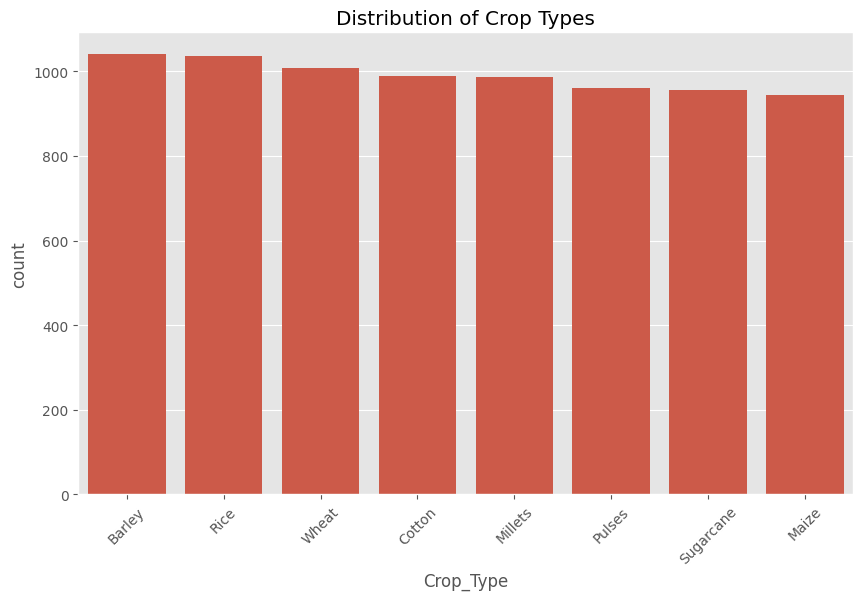

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='Crop_Type',
    order=df['Crop_Type'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Distribution of Crop Types')
plt.show()

## Rainfall Distribution

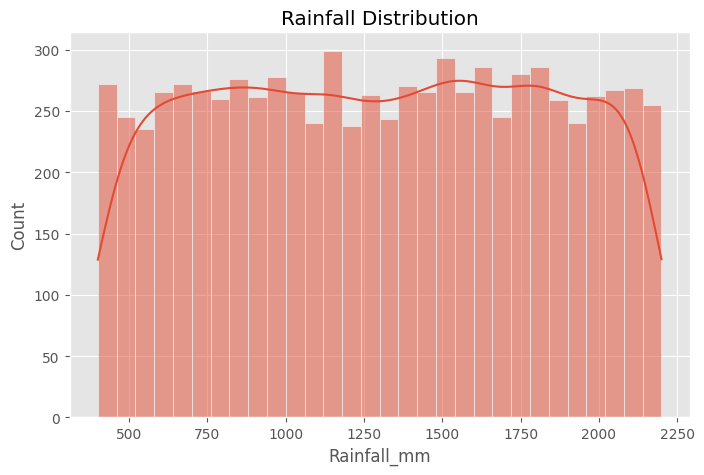

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rainfall_mm'],bins=30,kde=True)

plt.title('Rainfall Distribution')
plt.show()

## Crop Yield vs Rainfall

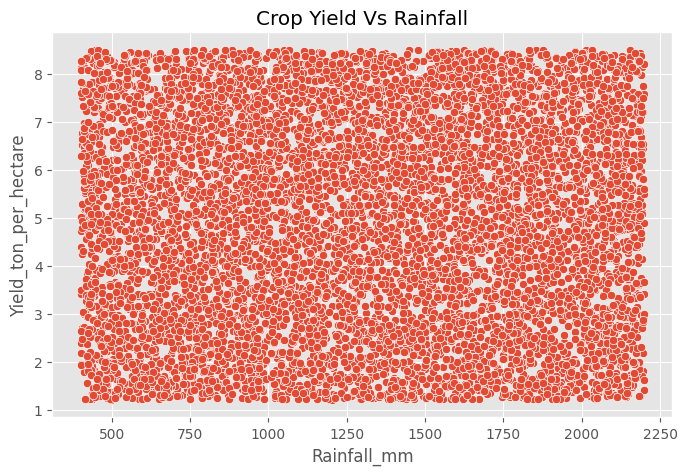

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_ton_per_hectare'
)

plt.title('Crop Yield Vs Rainfall')
plt.show()

## Correlation Heatmap

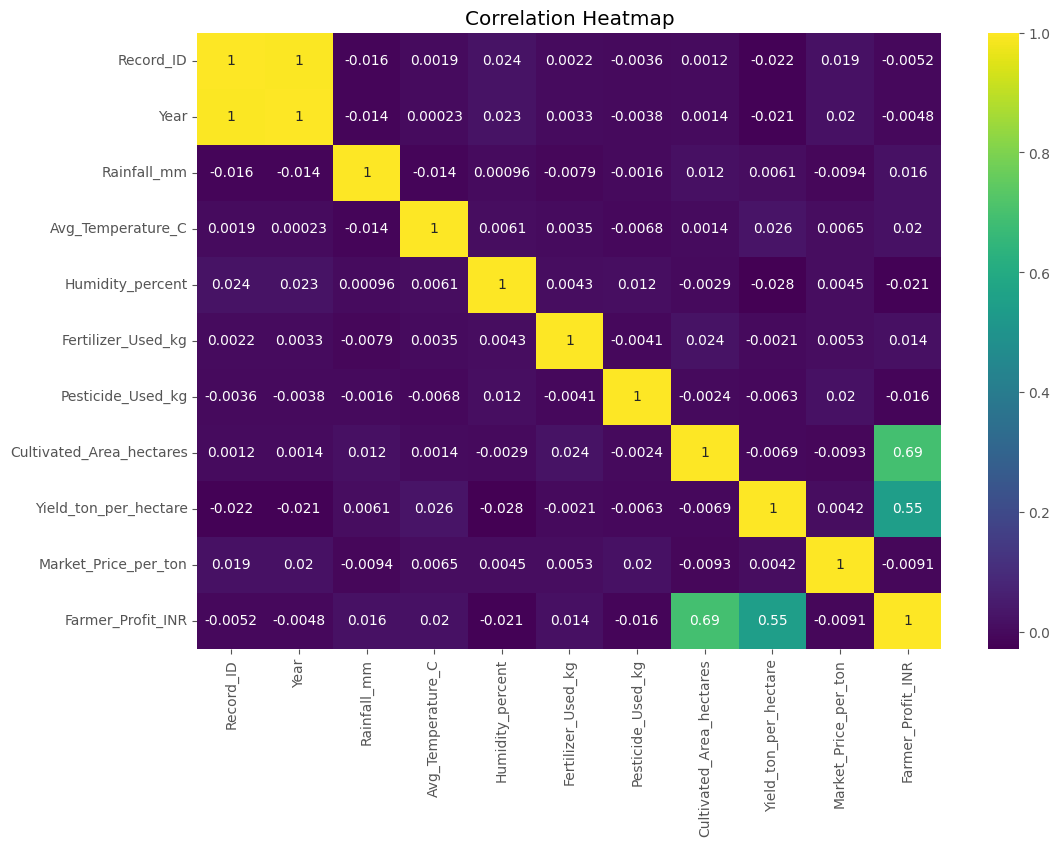

In [9]:
plt.figure(figsize=(12,8))

numeric_df=df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='viridis'
)

plt.title('Correlation Heatmap')
plt.show()

In [10]:
label_cols=[
    'State',
    'District',
    'Season',
    'Crop_Type',
    'Soil_Type',
    'Irrigation_Type'
]

le=LabelEncoder()

for col in label_cols:
    df[col]=le.fit_transform(df[col])

df.head()

,Record_ID,State,District,Year,Season,Crop_Type,Rainfall_mm,Avg_Temperature_C,Humidity_percent,Soil_Type,Irrigation_Type,Fertilizer_Used_kg,Pesticide_Used_kg,Cultivated_Area_hectares,Yield_ton_per_hectare,Market_Price_per_ton,Farmer_Profit_INR
0,1,6,11,2014,0,5,445.02,23.5,47.3,1,3,344.59,42.22,4471.68,1.83,34361.86,67904.0
1,2,6,11,2014,1,7,1410.24,32.3,73.6,3,2,217.81,29.71,1463.13,7.55,52216.79,106010.0
2,3,6,11,2014,0,2,787.56,33.3,40.6,2,0,201.97,24.74,1785.38,3.13,14302.87,70380.0
3,4,6,11,2014,0,1,1892.93,30.4,82.4,0,4,280.94,43.75,324.54,2.86,27337.56,8166.0
4,5,6,11,2014,2,1,1216.14,34.7,43.9,1,1,192.11,41.86,3538.92,6.19,15784.33,314345.0


# Feature Selection

In [11]:
y=df['Yield_ton_per_hectare']

x=df.drop([
    'Yield_ton_per_hectare',
    'Record_ID'
],axis=1)

print('Feature Shape:',x.shape)

Feature Shape: (7920, 15)


# Train-Test Split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)
print('Training Shape:',x_train.shape)
print('Testing Shape:',x_test.shape)

Training Shape: (6336, 15)
Testing Shape: (1584, 15)


# Model Training — Random Forest Regressor

In [13]:
model=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# Predictions

In [14]:
y_pred=model.predict(x_test)

# Model Evaluation

In [15]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

In [16]:
print("MAE:",mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2 SCORE:',r2)

MAE: 0.7799154987373736
MSE: 0.9432477250110477
RMSE: 0.9712094135720925
R2 SCORE: 0.7847672169575989


# Feature Importance Analysis

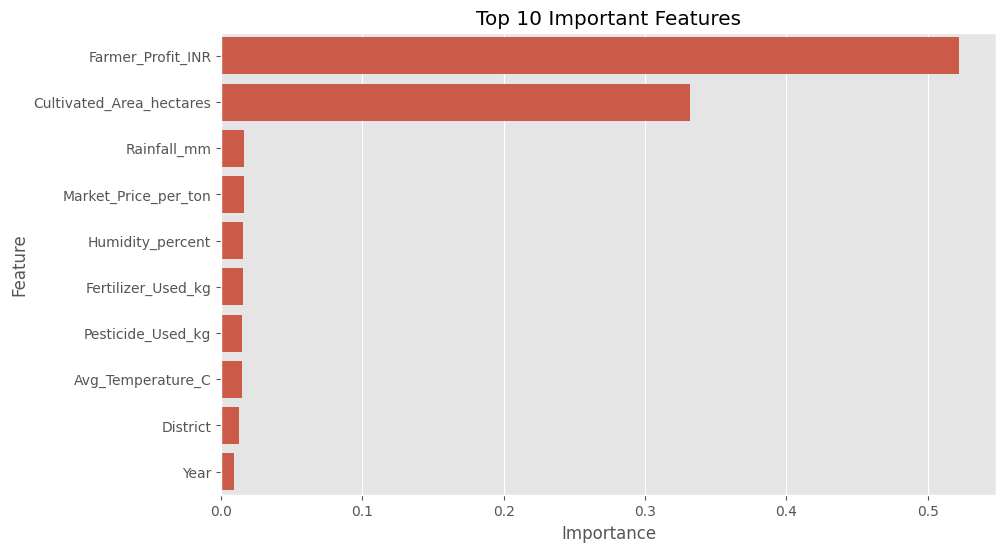

In [17]:
importance=pd.DataFrame({
    'Feature':x.columns,
    'Importance':model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

# Final Conclusion

## Model Performance Summary

The Random Forest Regressor produced strong predictive performance for crop yield estimation.

### Evaluation Metrics

- MAE: 0.7799
- MSE: 0.9432
- RMSE: 0.9712
- R² Score: 0.7848

The model explains nearly 78% of the variation in crop yield, indicating strong predictive capability.

This shows that agricultural and climate variables such as rainfall, irrigation methods, soil quality, cultivated area, and fertilizer usage play a significant role in determining crop productivity.

## Key Findings

- Rainfall strongly affects crop yield
- Irrigation type improves productivity prediction
- Soil type contributes significantly
- Cultivated area impacts final production
- Random Forest performs effectively for regression tasks

## Project Use Cases

- Agricultural forecasting
- Smart farming analytics
- Climate change studies
- Machine learning regression projects
- Final-year academic projects

This notebook demonstrates how data science and machine learning can support better agricultural planning and crop management decisions.